# Exercise 1

## Importing data

In [1]:
import seaborn as sns
import pickle
import sys
import os
sys.path.append(os.path.abspath("neural-data-master/01-local_field_potential/code")) #where to find the utils.py
from utils import download_data
import lfp_functions as lf

sns.set_theme(context='notebook',style='white',font_scale=1.5,
               rc = {'axes.spines.top':False,'axes.spines.right':False})
download_data('https://surfdrive.surf.nl/files/index.php/s/9nY01qMimFLez40') #loading the data

#opening the data for usage
with open('data/moving_lfp.pickle', 'rb') as handle:
    lfp_data = pickle.load(handle)


## Frequency bands
### Different frequency bands

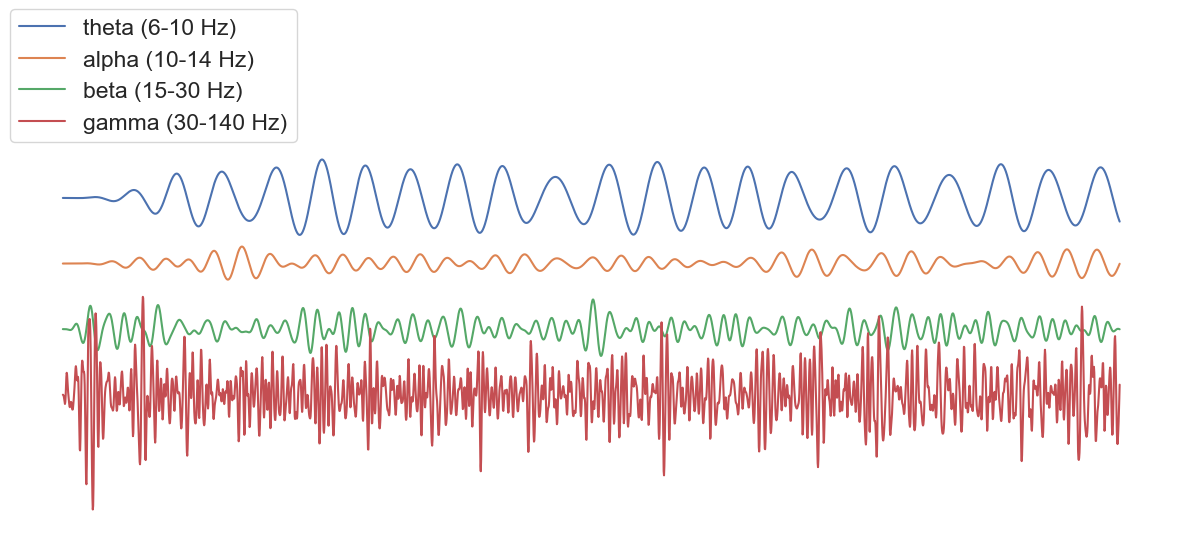

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

lfp = lfp_data['lfp'] #voltage over time (mV)
sampling_rate = lfp_data['sampling_rate'] #samples per second (Hz)

n_samples = len(lfp) #amount of data points
sample_dt = 1. / sampling_rate #time between samples

theta_lfp = lf.bandpass_filter(lfp,low_f=6,high_f=10, sampling_rate=sampling_rate) #filtering theta frequency between 6-10 Hz
alpha_lfp = lf.bandpass_filter(lfp,low_f=10,high_f=14, sampling_rate=sampling_rate) #filtering alpha frequency between 10-14 Hz
beta_lfp = lf.bandpass_filter(lfp,low_f=15,high_f=30, sampling_rate=sampling_rate) #filtering beta frequency between 15-30 Hz
gamma_lfp = lf.bandpass_filter(lfp,low_f=30,high_f=140, sampling_rate=sampling_rate) #filtering gamma frequency between 30-140 Hz

plot_offset = 200 #to plot the signal on different lines

#plotting 3 seconds of different frequency bands
plt.figure(figsize=(15,5))
plt.plot(theta_lfp[:3000]+3*plot_offset,label='theta (6-10 Hz)')
plt.plot(alpha_lfp[:3000]+2*plot_offset,label = 'alpha (10-14 Hz)')
plt.plot(beta_lfp[:3000]+plot_offset,label = 'beta (15-30 Hz)')
plt.plot(gamma_lfp[:3000],label = 'gamma (30-140 Hz)')

plt.axis('off')
plt.legend(loc=(0,1))

> We see clearly that every frequency band looks different meaning that the lower the frequency (like theta) the smoother and slower it moves compared to a high frequency (like gamma) which oscillates more and has more outliers.

### Fixed central frequency, different width bands

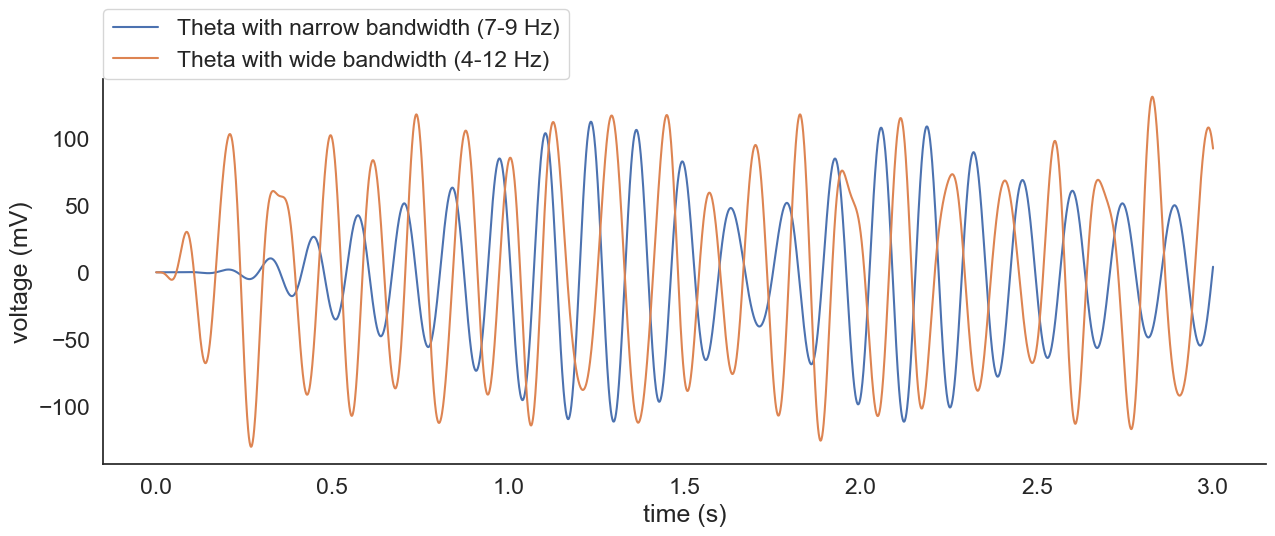

In [11]:
theta_narrow=lf.bandpass_filter(lfp,low_f=7,high_f=9, sampling_rate=sampling_rate) #bandwidth=2
theta_wide=lf.bandpass_filter(lfp,low_f=4,high_f=12, sampling_rate=sampling_rate) #bandwidth=8

#plotting 3 seconds of different bandwidths
plt.figure(figsize=(15,5))
plt.plot(np.linspace(0,3,3000), theta_narrow[:3000],label = 'Theta with narrow bandwidth (7-9 Hz)') 
plt.plot(np.linspace(0,3,3000), theta_wide[:3000],label = 'Theta with wide bandwidth (4-12 Hz)')
plt.xlabel("time (s)")
plt.ylabel("voltage (mV)")
plt.legend(loc=(0,1))


> So we see that a wide bandwidth will give higher voltages as well have more oscillations. This makes sense since we have more frequencies packed in it. A narrow bandwidth will however make it look smoother.

### Different central frequencies

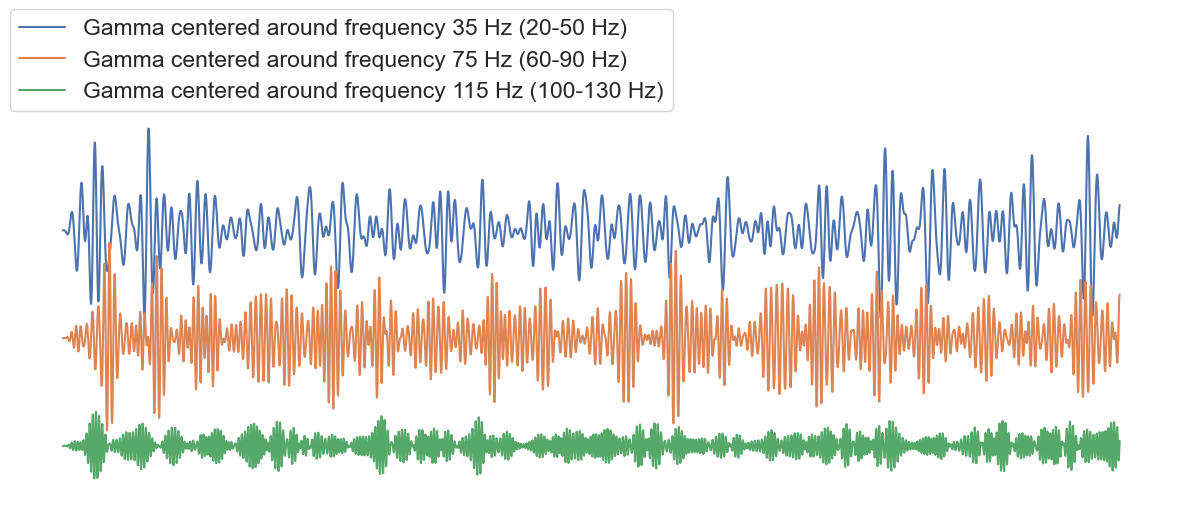

In [4]:
#bandwidth = 30
gamma_low = lf.bandpass_filter(lfp,low_f=20,high_f=50, sampling_rate=sampling_rate) #midpoint 35
gamma_middle = lf.bandpass_filter(lfp,low_f=60,high_f=90, sampling_rate=sampling_rate) #midpoint 75
gamma_high = lf.bandpass_filter(lfp,low_f=100,high_f=130, sampling_rate=sampling_rate) #midpoint 115

#plotting 3 seconds of different gamma frequency bands
plt.figure(figsize=(15,5))
plt.plot(gamma_low[:3000]+2*plot_offset,label = 'Gamma centered around frequency 35 Hz (20-50 Hz)')
plt.plot(gamma_middle[:3000]+plot_offset,label = 'Gamma centered around frequency 75 Hz (60-90 Hz)')
plt.plot(gamma_high[:3000],label = 'Gamma centered around frequency 115 Hz (100-130 Hz)')
plt.axis('off')
plt.legend(loc=(0,1))

> Again a high center has more oscillations since it contains higher frequencies. And how higher the center, how more irregulations in the wave. 

## Order of filter

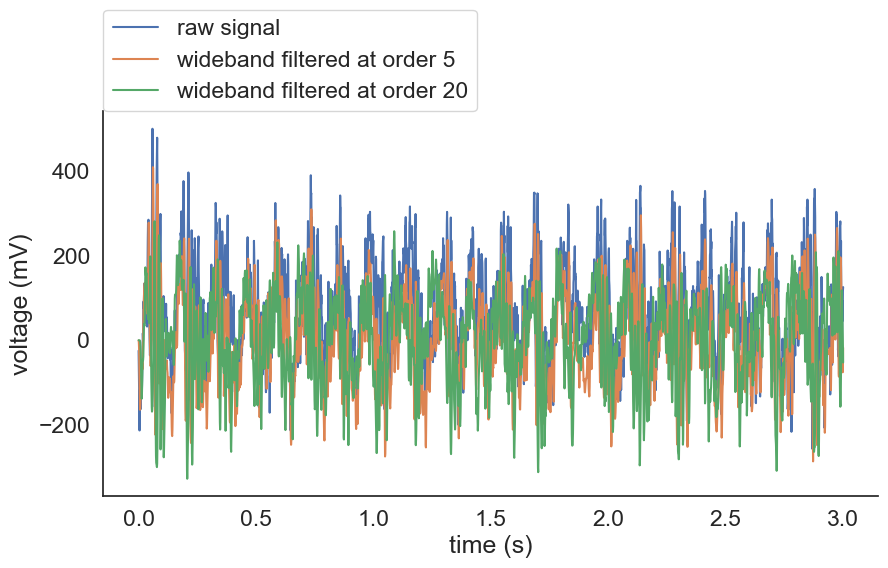

In [5]:
from scipy.signal import butter
from scipy.signal import sosfilt

filter_order1 = 5 #starter filter
filter_order2 = 20 #sharper filtering

#frequency window
low_f = 1
high_f = 200

#define filter object
filter1 = butter(filter_order1,[low_f,high_f],
                btype='band', 
                output='sos', 
                fs=sampling_rate)
filter2 = butter(filter_order2,[low_f,high_f],
                btype='band', 
                output='sos', 
                fs=sampling_rate)
                
#apply filter to lfp       
wideband_lfp1 = sosfilt(filter1, lfp)
wideband_lfp2 = sosfilt(filter2, lfp)

#plotting 3 seconds of differently filtered signals
plt.figure(figsize=(10,5))
plt.plot(np.linspace(0,3,3000),lfp[:3000],label='raw signal')
plt.plot(np.linspace(0,3,3000),wideband_lfp1[:3000],label='wideband filtered at order 5')
plt.plot(np.linspace(0,3,3000),wideband_lfp2[:3000],label = 'wideband filtered at order 20')
plt.xlabel('time (s)')
plt.ylabel('voltage (mV)')
plt.legend(loc=(0,1))

In [6]:
%timeit sosfilt(filter1, lfp)
%timeit sosfilt(filter2, lfp)

9.58 ms ± 43.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
14.3 ms ± 80.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


> The difference between the filtered signals are small, especially if you only look at the non-raw signals. The computing times are also minimal for my chosen orders.

# Exercise 2

Text(0, 0.5, 'frequency (Hz)')

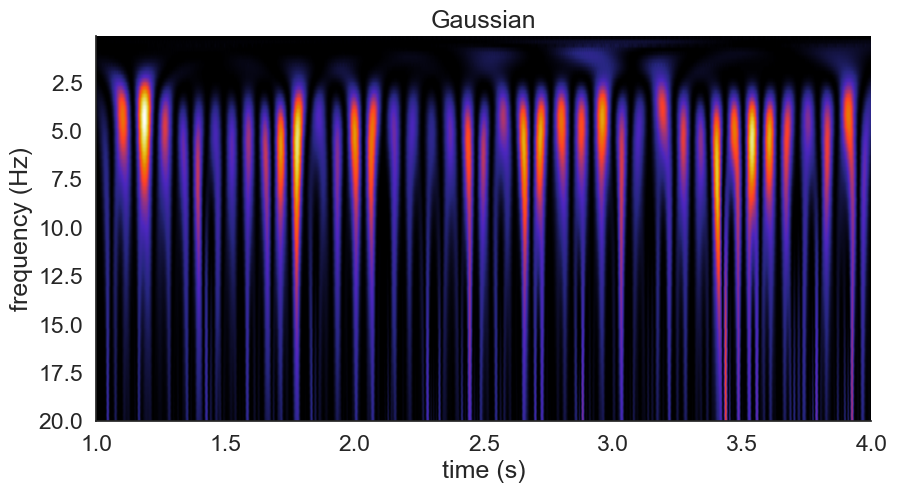

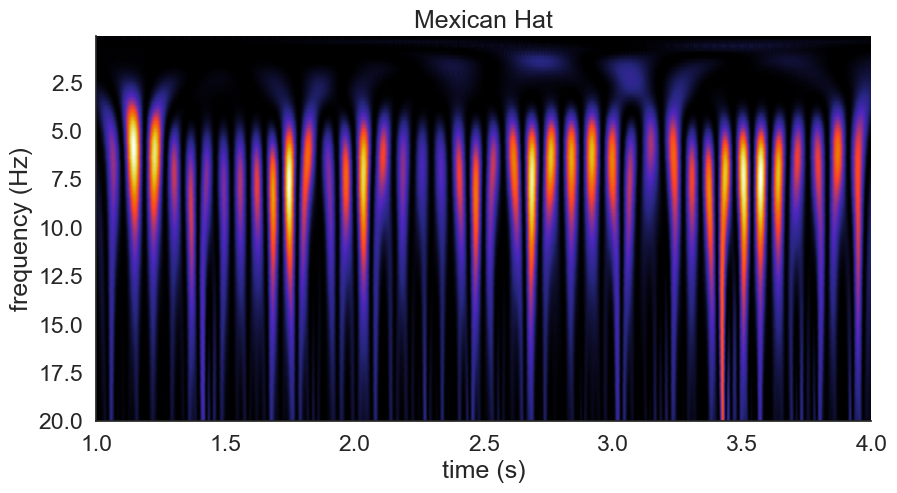

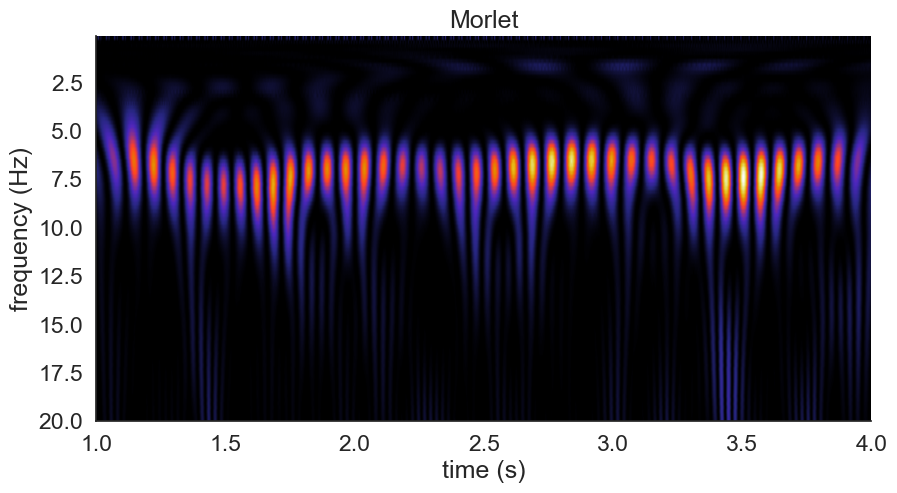

In [9]:
from pywt import scale2frequency
from pywt import cwt

#period of a few seconds
start = 1
end = 4

sig = lfp[int(start*sampling_rate):int(end*sampling_rate)] #extracts portions of lfp between 1 and 4 seconds
sig = sig - np.mean(sig) # get rid of 0 frequency component

#spectrogram with gaussian transform
frequencies =  np.linspace(0.1,20,100)/sampling_rate
wavelet = 'gaus1'
scales = scale2frequency(wavelet, frequencies)
cwtmatr, _ = cwt(sig, wavelet=wavelet, scales=scales,
                  sampling_period=1.0/sampling_rate) #applying continuous wavelet transform
plt.figure(figsize=(10,5))
plt.imshow(abs(cwtmatr)**2, extent=[start,end,frequencies[-1]*sampling_rate,
                         frequencies[0]*sampling_rate], aspect='auto', cmap='CMRmap')
plt.title('Gaussian')
plt.xlabel('time (s)')
plt.ylabel('frequency (Hz)')

#spectrogram with mexican hat transform
frequencies =  np.linspace(0.1,20,100)/sampling_rate
wavelet = 'mexh'
scales = scale2frequency(wavelet, frequencies)
cwtmatr, _ = cwt(sig, wavelet=wavelet, scales=scales,
                  sampling_period=1.0/sampling_rate) #applying continuous wavelet transform
plt.figure(figsize=(10,5))
plt.imshow(abs(cwtmatr)**2, extent=[start,end,frequencies[-1]*sampling_rate,
                         frequencies[0]*sampling_rate], aspect='auto', cmap='CMRmap')
plt.title('Mexican Hat')
plt.xlabel('time (s)')
plt.ylabel('frequency (Hz)')

#spectrogram with morlet transform
frequencies =  np.linspace(0.1,20,100)/sampling_rate
wavelet = 'morl'
scales = scale2frequency(wavelet, frequencies)
cwtmatr, _ = cwt(sig, wavelet=wavelet, scales=scales,
                  sampling_period=1.0/sampling_rate) #applying continuous wavelet transform
plt.figure(figsize=(10,5))
plt.imshow(abs(cwtmatr)**2, extent=[start,end,frequencies[-1]*sampling_rate,
                         frequencies[0]*sampling_rate], aspect='auto', cmap='CMRmap')
plt.title('Morlet')
plt.xlabel('time (s)')
plt.ylabel('frequency (Hz)')

> The vertical stripes we see mean that there are spikes of activities, so meany frequencies respond but only briefly. This can be explained by a sudden event. The changes in colors (black to purple to yellow) indicate a change in power (how strongly certain frequencies are present). So the 'yellow blobs' at frequencies 5.0-7.5 Hz show that at these times the signal behaves like those frequency oscillations. The morlet wavelet spectrogram seems to have its own oscillation-like shape.

Text(0, 0.5, 'frequency (Hz)')

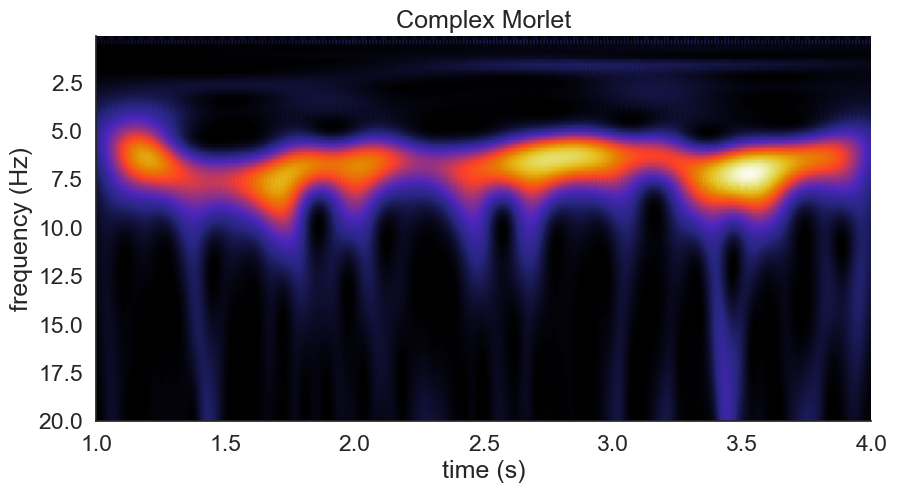

In [10]:
#spectrogram with complex morlet transform
frequencies =  np.linspace(0.1,20,100)/sampling_rate
wavelet = 'cmor1.0-1.0'
scales = scale2frequency(wavelet, frequencies)
cwtmatr, _ = cwt(sig, wavelet=wavelet, scales=scales,
                  sampling_period=1.0/sampling_rate) #applying continuous wavelet transform
plt.figure(figsize=(10,5))
plt.imshow(abs(cwtmatr)**2, extent=[start,end,frequencies[-1]*sampling_rate,
                         frequencies[0]*sampling_rate], aspect='auto', cmap='CMRmap')
plt.title('Complex Morlet')
plt.xlabel('time (s)')
plt.ylabel('frequency (Hz)')

> The main difference we see is that for the complex morlet there are horizontal stripes/blobs which are not present for the real wavelets. This means that a frequency window is repeated over time, making a stable oscillation (likely the theta brain wave in this case). We can also read the phase of the signal in this spectrogram. 